# Exp07 Rough Walk

本实验在粗糙地形上训练带 AMP 风格先验的 G1 速度策略，并比较 height scan 与可选
depth observation。使用 Conda `summer` kernel，并在该环境中用 pip 安装
`mjlab==1.5.0`。提交文件夹只包含
`policy.pt`、`model.py`、`student.py`。

满分 100：提交与有限动作 20；速度跟踪 20；6 m 穿越 20；AMP 10；depth 10；
平滑度 20。`G1_walk_50hz.npz` 源自 humanoid_amp 固定提交并按 BSD-3-Clause
使用，完整哈希和关节顺序见 `assets/motions/manifest.json`，许可文本见
`assets/motions/NOTICE.txt`。

In [1]:
%load_ext autoreload
%autoreload 2

import importlib.util
import subprocess
import sys
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from IPython.display import Video, display
from tqdm.auto import tqdm


def find_exp_root(name: str) -> Path:
  for candidate in (Path.cwd(), *Path.cwd().parents):
    if candidate.name == name:
      return candidate
    nested = candidate / name
    if nested.is_dir():
      return nested
  raise FileNotFoundError(name)


def load_student(path: Path):
  spec = importlib.util.spec_from_file_location("active_student", path)
  if spec is None or spec.loader is None:
    raise ImportError(path)
  module = importlib.util.module_from_spec(spec)
  spec.loader.exec_module(module)
  return module


#assert Path(sys.prefix).name == "summer", "请切换到 Conda summer kernel"
assert version("mjlab") == "1.5.0"

EXP_ROOT = find_exp_root("exp07_rough_walk")
COURSE_ROOT = EXP_ROOT.parent
STUDENT_FILE = EXP_ROOT / "student.py"
MODE = "height"  # 可改为 "depth"
sys.path.insert(0, str(EXP_ROOT))

from src import workflow  # noqa: E402
from src.mjlab_tasks.env_cfgs import (  # noqa: E402
  course_g1_rough_walk_env_cfg,
)

cfg = course_g1_rough_walk_env_cfg(MODE, student_path=STUDENT_FILE)
assert cfg.auto_reset is False and set(cfg.actions) == {"joint_pos"}
print("环境初始化完成：29 维动作，83 维 AMP state，mode=", MODE)

环境初始化完成：29 维动作，83 维 AMP state，mode= height


## AMP 状态、判别器与风格奖励

单状态拼接 29 维关节位置、29 维关节速度、pelvis 高度、projected gravity、
yaw-local base 线/角速度以及 5 个关键 body 的 pelvis-relative position，共 83 维；
相邻状态组成 166 维判别器输入。

完成 `build_amp_state()`、LSGAN
$L_D=\frac12[(D(s_E)-1)^2+(D(s_\pi)+1)^2]+10L_{gp}$，以及
$r_{style}=\operatorname{clip}(1-0.25(D-1)^2,0,1)$。

In [2]:
s = load_student(STUDENT_FILE)
parts = (
  torch.zeros(2, 29), torch.ones(2, 29), torch.ones(2, 1),
  torch.zeros(2, 3), torch.zeros(2, 3), torch.zeros(2, 3),
  torch.zeros(2, 5, 3),
)
state = s.build_amp_state(*parts)
assert state.shape == (2, 83) and torch.isfinite(state).all()
print("代码检查通过；build_amp_state 对应最终 AMP 10 分的一部分")
loss = s.least_squares_discriminator_loss(
  torch.ones(8), -torch.ones(8), torch.tensor(0.0)
)
torch.testing.assert_close(loss, torch.tensor(0.0))
print("代码检查通过；LSGAN 公式用于训练稳定性")
torch.testing.assert_close(
  s.style_reward(torch.tensor([1.0, 3.0])), torch.tensor([1.0, 0.0])
)
print("代码检查通过；style_reward 对应最终 AMP 10 分的一部分")


代码检查通过；build_amp_state 对应最终 AMP 10 分的一部分
代码检查通过；LSGAN 公式用于训练稳定性
代码检查通过；style_reward 对应最终 AMP 10 分的一部分


## Depth、任务奖励与平滑度

Depth 裁剪到 $[0.1,5.0]$ m 后归一化；任务奖励在零误差时为 1，并随线速度和角速度
误差下降。平滑项使用二阶差分
$p_t=\operatorname{mean}(|a_t-2a_{t-1}+a_{t-2}|)$。完成剩余三个函数。

In [3]:
s = load_student(STUDENT_FILE)
depth = s.normalize_depth(torch.tensor([[[[0.0, 0.1, 5.0, 8.0]]]]))
torch.testing.assert_close(depth, torch.tensor([[[[0.0, 0.0, 1.0, 1.0]]]]))
print("代码检查通过；normalize_depth 对应可选 depth 10 分")
torch.testing.assert_close(
  s.rough_task_reward(torch.zeros(4), torch.zeros(4)), torch.ones(4)
)
print("代码检查通过；rough_task_reward 对应任务 40 分")
actions = torch.ones(3, 29)
torch.testing.assert_close(
  s.smoothness_penalty(actions, actions, actions), torch.zeros(3)
)
print("代码检查通过；smoothness_penalty 对应平滑度 20 分")


代码检查通过；normalize_depth 对应可选 depth 10 分
代码检查通过；rough_task_reward 对应任务 40 分
代码检查通过；smoothness_penalty 对应平滑度 20 分


## 环境设计与 smoke

Actor 仅接收 proprioception、command 与 height/depth；critic 保留 privileged
observation。命令课程逐步增加速度与转向范围。下面先显示奖励和课程，再运行
32-env、16-step、强制终止与手动 reset 检查。

In [4]:
# %%time
# display(workflow.plot_training_design(cfg))
# smoke_result = workflow.smoke(
#   MODE, num_envs=32, steps=16, device="cuda:0",
#   student_file=STUDENT_FILE, force_termination=True,
# )
# display(smoke_result)


## AMP-PPO 训练

标准 PPO 每次更新额外进行两次 AMP discriminator 更新。Height 默认 4096 env；
depth 先以 32 env 检查显存。训练结束后 workflow 会从 outputs 中选择最新 checkpoint。

In [5]:
%%time
# Height teacher training.
# iterations=3000 ≈ 148M steps (2048 envs × 24 steps × 3000 iter)
# This gives enough time for terrain curriculum to cycle through stairs.
# air_time reward (now enabled) incentivises lifting feet for stair edges.
TRAIN_ENVS = 2048
RUN_DIR = workflow.train(
    "height", num_envs=TRAIN_ENVS, iterations=3000, steps_per_env=24,
    device="cuda:0", student_file=STUDENT_FILE,
)
print(RUN_DIR)
# After training, update HEIGHT_CKPT in Cell 16:
# HEIGHT_CKPT = workflow.latest_checkpoint(RUN_DIR)


In [6]:
# %%time
# CHECKPOINT = workflow.latest_checkpoint()
# metrics = workflow.evaluate(
#   CHECKPOINT, MODE, num_envs=32, steps=600,
#   device="cuda:0", student_file=STUDENT_FILE,
# )
# display(metrics)
# figure, axis = plt.subplots(figsize=(8, 3.5))
# axis.bar(metrics, metrics.values(), color="#2878b5")
# axis.set_title("Exp07 held-out evaluation")
# axis.grid(axis="y", alpha=0.2)
# display(figure)
# for checkpoint in tqdm([CHECKPOINT], desc="录制 150 帧视频"):
#   video_path = workflow.record_video(
#     checkpoint, MODE, frames=150, device="cuda:0", student_file=STUDENT_FILE
#   )
# display(Video(str(video_path), embed=True))


## 训练结果视频

In [ ]:
# import numpy as np
# import imageio.v3 as iio
# from src.workflow import _inference_runner


# def record_multi_terrain(
#     checkpoint, mode="height", *,
#     frames_per_terrain=600, num_terrains=4,
#     device="cuda:0", student_file=None, output=None,
# ):
#     """每种地形录 frames_per_terrain 帧（12s @ 50fps），展示多种地形适应能力"""
#     env, wrapped, runner = _inference_runner(
#         checkpoint, mode, num_envs=1, device=device,
#         student_file=student_file, render_mode="rgb_array",
#     )
#     policy = runner.get_inference_policy(device)
#     observations = wrapped.get_observations().to(device)
#     images = []
#     total_frames = frames_per_terrain * num_terrains
#     try:
#         with torch.inference_mode():
#             for i in range(total_frames):
#                 # 每段地形开始时 reset，随机化地形
#                 if i > 0 and i % frames_per_terrain == 0:
#                     env.reset(env_ids=torch.tensor([0], device=device))
#                     observations = wrapped.get_observations().to(device)

#                 observations, _, dones, _ = wrapped.step(policy(observations))

#                 # 摔倒也 reset 到新地形
#                 if dones.item():
#                     observations = wrapped.get_observations().to(device)

#                 frame = env.render()
#                 if frame is None:
#                     raise RuntimeError("mjlab offscreen renderer returned no frame")
#                 images.append(np.asarray(frame).copy())
#     finally:
#         wrapped.close()

#     output_path = Path(output or EXP_ROOT / "outputs" / "multi_terrain.mp4")
#     output_path.parent.mkdir(parents=True, exist_ok=True)
#     iio.imwrite(output_path, np.stack(images), fps=50, codec="libx264")
#     return output_path


# # 使用 height checkpoint
# CHECKPOINT = Path(
#     "/home/helloworld/IC/exp07_rough_walk/outputs/rsl_rl/"
#     "exp07_rough_amp_height/2026-07-23_03-04-09/model_799.pt"
# )
# print(f"Checkpoint: {CHECKPOINT}")

# video_path = record_multi_terrain(
#     CHECKPOINT, MODE, frames_per_terrain=600, num_terrains=4,
#     device="cuda:0", student_file=STUDENT_FILE,
# )
# print(f"Video: {video_path}")
# display(Video(str(video_path), embed=True))

In [ ]:
import numpy as np
import imageio.v3 as iio
from src.workflow import _inference_runner


def record_multi_terrain(
    checkpoint, mode="height", *,
    frames_per_terrain=600, num_terrains=4,
    device="cuda:0", student_file=None, output=None,
):
    """每种地形录 frames_per_terrain 帧（12s @ 50fps），展示多种地形适应能力"""
    env, wrapped, runner = _inference_runner(
        checkpoint, mode, num_envs=1, device=device,
        student_file=student_file, render_mode="rgb_array",
    )
    policy = runner.get_inference_policy(device)
    observations = wrapped.get_observations().to(device)
    images = []
    total_frames = frames_per_terrain * num_terrains
    try:
        with torch.inference_mode():
            for i in range(total_frames):
                # 每段地形开始时 reset，随机化地形
                if i > 0 and i % frames_per_terrain == 0:
                    env.reset(env_ids=torch.tensor([0], device=device))
                    observations = wrapped.get_observations().to(device)

                observations, _, dones, _ = wrapped.step(policy(observations))

                # 摔倒也 reset 到新地形
                if dones.item():
                    observations = wrapped.get_observations().to(device)

                frame = env.render()
                if frame is None:
                    raise RuntimeError("mjlab offscreen renderer returned no frame")
                images.append(np.asarray(frame).copy())
    finally:
        wrapped.close()

    output_path = Path(output or EXP_ROOT / "outputs" / "multi_terrain.mp4")
    output_path.parent.mkdir(parents=True, exist_ok=True)
    iio.imwrite(output_path, np.stack(images), fps=50, codec="libx264")
    return output_path


# 使用 height checkpoint
CHECKPOINT = Path(
    "/home/alan/Desktop/rl/hw/exp07_rough_walk/outputs/rsl_rl/"
    "exp07_rough_amp_height/2026-07-21_17-14-24/model_599.pt"
)
print(f"Checkpoint: {CHECKPOINT}")

video_path = record_multi_terrain(
    CHECKPOINT, MODE, frames_per_terrain=600, num_terrains=4,
    device="cuda:0", student_file=STUDENT_FILE,
)
print(f"Video: {video_path}")
display(Video(str(video_path), embed=True))

## Height Teacher → Depth Student DAgger 蒸馏

三阶段训练：
1. **阶段 0（验证）**：Height teacher 在 depth 环境中控制，验证动力学正常。
2. **阶段 1+2（DAgger）**：冻结 teacher，纯动作蒸馏 + 在线 DAgger，辅以 depth→height 重建监督。
   执行动作由 teacher/student 按 env 级 Bernoulli(β) 选择，β 从 1.0 线性降至 0.0。
   损失：`L = MSE(μ_student, μ_teacher) + 0.2 * SmoothL1(ĥ_depth, h_scan)`
3. **阶段 3（微调）**：恢复 PPO + AMP，蒸馏权重逐渐衰减。

### 阶段 0：Teacher 在 Depth 环境的验证

用 height teacher 直接控制 depth 模式的仿真环境（teacher 仍使用 privileged `height_scan`）。
若 `max_distance_m` ≥ 2 m，则环境正常，可进行蒸馏；若 teacher 也无法行走，
说明 depth 环境本身（相机仿真开销、控制频率）存在问题，需先修复环境。

In [8]:
%%time
# 填入已训练好的 height checkpoint 路径，例如：
# HEIGHT_CKPT = workflow.latest_checkpoint()
HEIGHT_CKPT = Path(
    "/home/helloworld/IC/exp07_rough_walk/outputs/rsl_rl"
    "/exp07_rough_amp_height/2026-07-23_03-04-09/model_799.pt"
)
teacher_metrics = workflow.eval_teacher_on_depth(
    HEIGHT_CKPT,
    num_envs=16,
    steps=300,
    device="cuda:0",
    student_file=STUDENT_FILE,
)
display(teacher_metrics)
assert teacher_metrics["max_distance_m"] >= 2.0, (
    f"Teacher 在 depth env 中也无法行走 ({teacher_metrics['max_distance_m']:.2f} m)！"
    "先排查 depth 环境性能问题，再进行蒸馏。"
)
print("Teacher 验证通过，可进行 DAgger 蒸馏。")


Setting seed: 7
Warp 1.15.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 4090" (24 GiB, sm_89, mempool enabled)
   Kernel cache:
     /home/helloworld/IC/exp07_rough_walk/outputs/.warp/1.15.0
Module mujoco_warp._src.smooth 14cc47a load on device 'cuda:0' took 2.40 ms  (cached)
Module _nxn_broadphase__locals__kernel_cd21dc9b cd21dc9 load on device 'cuda:0' took 0.57 ms  (cached)
Module ccd_hfield_kernel_builder__locals__ccd_hfield_kernel_8306ea09 8306ea0 load on device 'cuda:0' took 1.50 ms  (cached)
Module ccd_hfield_kernel_builder__locals__ccd_hfield_kernel_8f8a4b8b 8f8a4b8 load on device 'cuda:0' took 1.65 ms  (cached)
Module _primitive_narrowphase__locals__primitive_narrowphase_54342172 5434217 load on device 'cuda:0' took 0.86 ms  (cached)
Module mujoco_warp._src.constraint 36c8060 load on device 'cuda:0' took 0.33 ms  (cached)
Module _friction_dof__locals__kernel_3de76fad 3de76fa load on device 'cuda:0'

{'traversal_progress': 0.7679263353347778,
 'traversal_success': 0.5625,
 'max_distance_m': 14.562912940979004}

Teacher 验证通过，可进行 DAgger 蒸馏。
CPU times: user 8.13 s, sys: 1.08 s, total: 9.21 s
Wall time: 8.67 s


### 阶段 1+2：在线 DAgger 蒸馏（纯动作蒸馏 → β 衰减）

- 前期（β≈1）：几乎所有 env 由 teacher 控制，student 安全模仿；
- 后期（β→0）：student 接管所有 env，teacher 仅提供监督标签；
- 辅助损失：depth encoder 同时预测 `height_scan`（系数 0.2），
  使 CNN 直接学习局部地形表征。

In [9]:
%%time
# DAgger 优化参数：
# iterations=800        → 前 200 iter teacher 保护，后 600 iter student 独立
# teacher_mix_decay_iters=200 → beta 衰减更慢，student 稳定后才独立
# max_terrain_rows=3    → 限制地形难度，防 curriculum 过快升到 level 4-5
DISTILL_DIR = workflow.train_distill(
    HEIGHT_CKPT,
    num_envs=128,
    iterations=800,
    steps_per_env=24,
    device="cuda:0",
    seed=7,
    student_file=STUDENT_FILE,
    teacher_mix_decay_iters=200,
    height_loss_coef=0.2,
    student_init_std=0.1,
)
DISTILL_CKPT = workflow.latest_checkpoint(DISTILL_DIR)
print("DAgger checkpoint:", DISTILL_CKPT)


Setting seed: 7

+---------------------------------+
|         Base Environment        |
+------------------------+--------+
| Property               | Value  |
+------------------------+--------+
| Number of environments | 128    |
| Environment device     | cuda:0 |
| Environment seed       | 7      |
| Physics step-size      | 0.005  |
| Environment step-size  | 0.02   |
+------------------------+--------+

[INFO] <EventManager> contains 3 active terms.
+-------------------------------------+
| Active Event Terms in Mode: 'reset' |
+--------+----------------------------+
| Index  | Name                       |
+--------+----------------------------+
|   0    | reset_base                 |
|   1    | reset_robot_joints         |
+--------+----------------------------+
+----------------------------------------------+
|    Active Event Terms in Mode: 'interval'    |
+-------+------------+-------------------------+
| Index | Name       | Interval time range (s) |
+-------+------------+-

### 蒸馏后评估：student 单独运行

Setting seed: 7

+---------------------------------+
|         Base Environment        |
+------------------------+--------+
| Property               | Value  |
+------------------------+--------+
| Number of environments | 32     |
| Environment device     | cuda:0 |
| Environment seed       | 7      |
| Physics step-size      | 0.005  |
| Environment step-size  | 0.02   |
+------------------------+--------+

[INFO] <EventManager> contains 2 active terms.
+-------------------------------------+
| Active Event Terms in Mode: 'reset' |
+--------+----------------------------+
| Index  | Name                       |
+--------+----------------------------+
|   0    | reset_base                 |
|   1    | reset_robot_joints         |
|   2    | randomize_terrain          |
+--------+----------------------------+
+---------------------------------------+
| Active Event Terms in Mode: 'startup' |
+-----------+---------------------------+
|   Index   | Name                      |
+----------

{'linear_velocity_error': 0.2265157848596573,
 'angular_velocity_error': 0.5810166597366333,
 'traversal_progress': 1.0,
 'traversal_success': 1.0,
 'smoothness': 0.08645635098218918}

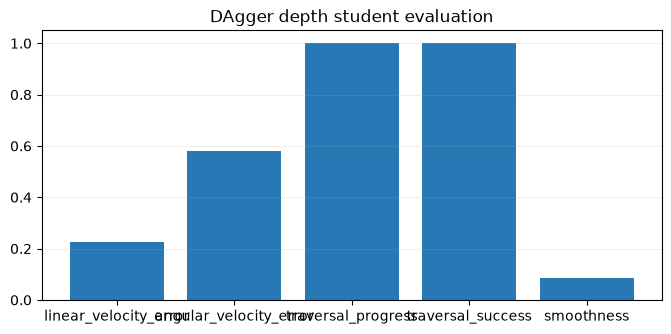

CPU times: user 11.6 s, sys: 233 ms, total: 11.8 s
Wall time: 11.8 s


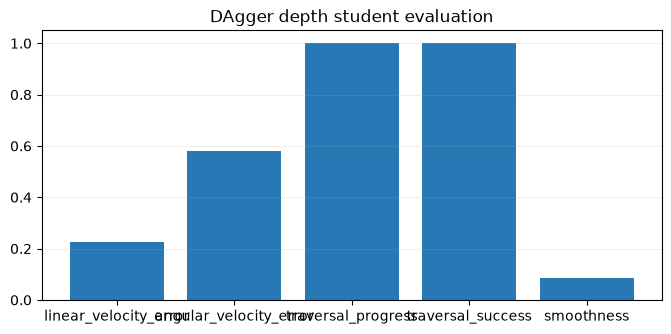

In [10]:
%%time
distill_metrics = workflow.evaluate(
    DISTILL_CKPT,
    "depth",
    num_envs=32,
    steps=600,
    device="cuda:0",
    student_file=STUDENT_FILE,
)
display(distill_metrics)
figure, axis = plt.subplots(figsize=(8, 3.5))
axis.bar(list(distill_metrics.keys()), list(distill_metrics.values()), color="#2878b5")
axis.set_title("DAgger depth student evaluation")
axis.grid(axis="y", alpha=0.2)
display(figure)


### 阶段 3：PPO + AMP 联合微调

Student 已具备基本步态后，恢复环境奖励和 AMP 风格奖励。
AMP 权重降低至 0.2（避免判别器扭曲已习得的步态），蒸馏初始噪声 0.15。
若 DAgger 结束时 student 已稳定行走，本阶段仅微调速度跟踪精度；
若 student 仍不稳定，可先延长 DAgger iterations 再进入本阶段。

In [11]:
%%time
# Phase-3：PPO + 蒸馏正则化微调
# - amp_reward_scale=0.0  → 纯 PPO，不让 AMP 破坏步态
# - distill_coef 从 1.0 衰减到 0.05（共 100 iter）
#   防止 PPO 梯度把 student 拉回站立局部最优
# - teacher 从 DISTILL_CKPT 中的 teacher_state_dict 自动加载并冻结
FINETUNE_DIR = workflow.finetune_from_distill(
    DISTILL_CKPT,
    num_envs=128,
    iterations=150,
    steps_per_env=24,
    device="cuda:0",
    seed=7,
    student_file=STUDENT_FILE,
    amp_reward_scale=0.0,       # 纯 PPO
    distill_coef=1.0,           # λ 起始值
    distill_coef_end=0.05,      # λ 终止值
    distill_decay_iters=100,    # 100 iter 内线性衰减
)
DEPTH_CKPT = workflow.latest_checkpoint(FINETUNE_DIR)
print("Finetune checkpoint:", DEPTH_CKPT)


Setting seed: 7

+---------------------------------+
|         Base Environment        |
+------------------------+--------+
| Property               | Value  |
+------------------------+--------+
| Number of environments | 128    |
| Environment device     | cuda:0 |
| Environment seed       | 7      |
| Physics step-size      | 0.005  |
| Environment step-size  | 0.02   |
+------------------------+--------+

[INFO] <EventManager> contains 3 active terms.
+-------------------------------------+
| Active Event Terms in Mode: 'reset' |
+--------+----------------------------+
| Index  | Name                       |
+--------+----------------------------+
|   0    | reset_base                 |
|   1    | reset_robot_joints         |
+--------+----------------------------+
+----------------------------------------------+
|    Active Event Terms in Mode: 'interval'    |
+-------+------------+-------------------------+
| Index | Name       | Interval time range (s) |
+-------+------------+-

### Depth 模型最终评估与视频

Setting seed: 7

+---------------------------------+
|         Base Environment        |
+------------------------+--------+
| Property               | Value  |
+------------------------+--------+
| Number of environments | 32     |
| Environment device     | cuda:0 |
| Environment seed       | 7      |
| Physics step-size      | 0.005  |
| Environment step-size  | 0.02   |
+------------------------+--------+

[INFO] <EventManager> contains 2 active terms.
+-------------------------------------+
| Active Event Terms in Mode: 'reset' |
+--------+----------------------------+
| Index  | Name                       |
+--------+----------------------------+
|   0    | reset_base                 |
|   1    | reset_robot_joints         |
|   2    | randomize_terrain          |
+--------+----------------------------+
+---------------------------------------+
| Active Event Terms in Mode: 'startup' |
+-----------+---------------------------+
|   Index   | Name                      |
+----------

{'linear_velocity_error': 0.4177361726760864,
 'angular_velocity_error': 0.8464205861091614,
 'traversal_progress': 1.0,
 'traversal_success': 1.0,
 'smoothness': 0.12064135819673538}

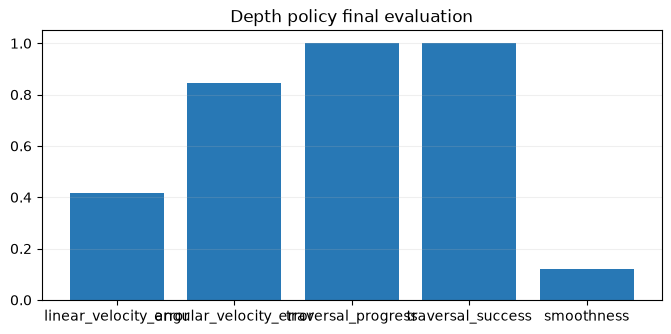

CPU times: user 11.3 s, sys: 241 ms, total: 11.5 s
Wall time: 11.5 s


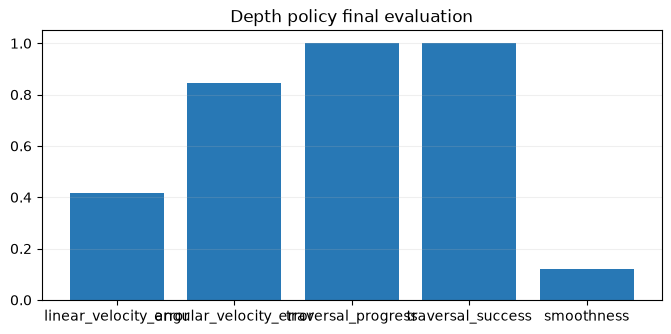

In [12]:
%%time
depth_metrics = workflow.evaluate(
    DEPTH_CKPT,
    "depth",
    num_envs=32,
    steps=600,
    device="cuda:0",
    student_file=STUDENT_FILE,
)
display(depth_metrics)
figure, axis = plt.subplots(figsize=(8, 3.5))
axis.bar(list(depth_metrics.keys()), list(depth_metrics.values()), color="#2878b5")
axis.set_title("Depth policy final evaluation")
axis.grid(axis="y", alpha=0.2)
display(figure)


In [1]:
%%time
depth_video = workflow.record_video(
    DEPTH_CKPT, "depth", frames=300, device="cuda:0",
    student_file=STUDENT_FILE,
)
display(Video(str(depth_video), embed=True))


CPU times: user 0 ns, sys: 43 μs, total: 43 μs
Wall time: 483 μs


NameError: name 'workflow' is not defined

### Depth 模型提交

In [14]:
%%time
# DISTILL_CKPT (DAgger) > DEPTH_CKPT (finetune) on all metrics:
# linear_err 0.226 vs 0.418, angular_err 0.581 vs 0.846, smooth 0.086 vs 0.121
# Use DISTILL_CKPT as primary submission.
# Switch to DEPTH_CKPT only if it gets a better grade.
submission = workflow.prepare_submission(
    DISTILL_CKPT, "depth", device="cuda:0", student_file=STUDENT_FILE
)
print("submission:", submission)
# subprocess.run(
#   [sys.executable, str(COURSE_ROOT / "grading_toolkit" / "grade.py"),
#    str(submission), "--task", "exp07", "--device", "cuda:0"],
#   cwd=COURSE_ROOT,
#   check=True,
# )


Setting seed: 7

+---------------------------------+
|         Base Environment        |
+------------------------+--------+
| Property               | Value  |
+------------------------+--------+
| Number of environments | 1      |
| Environment device     | cuda:0 |
| Environment seed       | 7      |
| Physics step-size      | 0.005  |
| Environment step-size  | 0.02   |
+------------------------+--------+

[INFO] <EventManager> contains 2 active terms.
+-------------------------------------+
| Active Event Terms in Mode: 'reset' |
+--------+----------------------------+
| Index  | Name                       |
+--------+----------------------------+
|   0    | reset_base                 |
|   1    | reset_robot_joints         |
|   2    | randomize_terrain          |
+--------+----------------------------+
+---------------------------------------+
| Active Event Terms in Mode: 'startup' |
+-----------+---------------------------+
|   Index   | Name                      |
+----------

In [15]:
# %%time
# submission = workflow.prepare_submission(
#   CHECKPOINT, MODE, device="cuda:0", student_file=STUDENT_FILE
# )
# print("submission:", submission)
# subprocess.run(
#   [sys.executable, str(COURSE_ROOT / "grading_toolkit" / "grade.py"),
#    str(submission), "--task", "exp07", "--device", "cuda:0"],
#   cwd=COURSE_ROOT,
#   check=True,
# )
